# COVID-19 CASES ANALYSIS

IMPORTING RAW DATA

In [218]:
import pandas as pd
url = "https://data.covid19india.org/csv/latest/case_time_series.csv"
df = pd.read_csv(url)
df
df.tail()

,Date,Date_YMD,Daily Confirmed,Total Confirmed,Daily Recovered,Total Recovered,Daily Deceased,Total Deceased
636,27 October 2021,2021-10-27,16351,34231030,17077,33606620,734,455828
637,28 October 2021,2021-10-28,14307,34245337,13189,33619809,805,456633
638,29 October 2021,2021-10-29,14215,34259552,13549,33633358,551,457184
639,30 October 2021,2021-10-30,12940,34272492,14672,33648030,445,457629
640,31 October 2021,2021-10-31,12907,34285399,13152,33661182,251,457880


In [219]:
df.drop("Date_YMD",axis = 1,inplace=True)
df = df.head(100)
df.to_csv(r"C:\Users\mail4\Downloads\data - Copy.csv",index = False)


In [220]:
df

,Date,Daily Confirmed,Total Confirmed,Daily Recovered,Total Recovered,Daily Deceased,Total Deceased
0,30 January 2020,1,1,0,0,0,0
1,31 January 2020,0,1,0,0,0,0
2,1 February 2020,0,1,0,0,0,0
3,2 February 2020,1,2,0,0,0,0
4,3 February 2020,1,3,0,0,0,0
...,...,...,...,...,...,...,...
95,4 May 2020,3656,46434,1082,12845,103,1566
96,5 May 2020,2971,49405,1295,14140,128,1694
97,6 May 2020,3602,53007,1161,15301,91,1785
98,7 May 2020,3344,56351,1475,16776,104,1889


In [221]:
df = pd.read_csv(r"C:\Users\mail4\Downloads\data - Copy.csv")
df

,Date,Daily Confirmed,Total Confirmed,Daily Recovered,Total Recovered,Daily Deceased,Total Deceased
0,30 January 2020,1,1,0,0,0,0
1,31 January 2020,0,1,0,0,0,0
2,1 February 2020,0,1,0,0,0,0
3,2 February 2020,1,2,0,0,0,0
4,3 February 2020,1,3,0,0,0,0
...,...,...,...,...,...,...,...
95,4 May 2020,3656,46434,1082,12845,103,1566
96,5 May 2020,2971,49405,1295,14140,128,1694
97,6 May 2020,3602,53007,1161,15301,91,1785
98,7 May 2020,3344,56351,1475,16776,104,1889


In [222]:
df["Date"] = pd.to_datetime(df["Date"],errors = "coerce").dt.strftime("%d/%m/%Y")
df.to_csv(r"C:\Users\mail4\Downloads\data - Copy.csv",index = False)

In [223]:
df

,Date,Daily Confirmed,Total Confirmed,Daily Recovered,Total Recovered,Daily Deceased,Total Deceased
0,30/01/2020,1,1,0,0,0,0
1,31/01/2020,0,1,0,0,0,0
2,01/02/2020,0,1,0,0,0,0
3,02/02/2020,1,2,0,0,0,0
4,03/02/2020,1,3,0,0,0,0
...,...,...,...,...,...,...,...
95,04/05/2020,3656,46434,1082,12845,103,1566
96,05/05/2020,2971,49405,1295,14140,128,1694
97,06/05/2020,3602,53007,1161,15301,91,1785
98,07/05/2020,3344,56351,1475,16776,104,1889


In [224]:
df

,Date,Daily Confirmed,Total Confirmed,Daily Recovered,Total Recovered,Daily Deceased,Total Deceased
0,30/01/2020,1,1,0,0,0,0
1,31/01/2020,0,1,0,0,0,0
2,01/02/2020,0,1,0,0,0,0
3,02/02/2020,1,2,0,0,0,0
4,03/02/2020,1,3,0,0,0,0
...,...,...,...,...,...,...,...
95,04/05/2020,3656,46434,1082,12845,103,1566
96,05/05/2020,2971,49405,1295,14140,128,1694
97,06/05/2020,3602,53007,1161,15301,91,1785
98,07/05/2020,3344,56351,1475,16776,104,1889


# DATA VISUALISATION AND ANALYSIS

## CASES OVER TIME

Question: How did COVID-19 cases change over time?

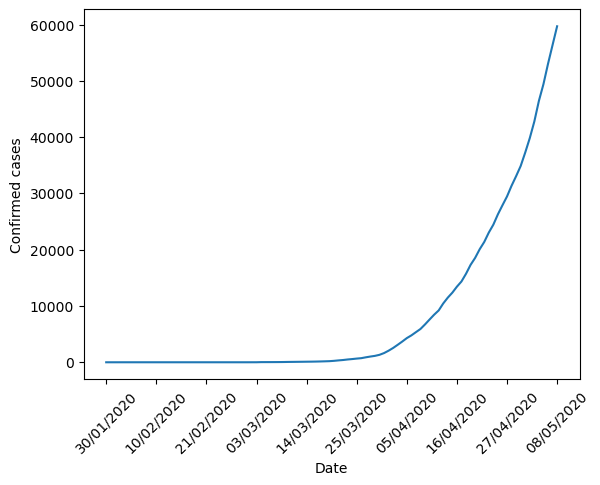

In [235]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.lineplot(data=df,x="Date",y="Total Confirmed")
plt.xticks(df["Date"][::11],rotation=45)
plt.xlabel("Date")
plt.ylabel("Confirmed cases")
plt.show()

### INSIGHT:
* The number of daily confirmed cases increased significantly over the analyzed period, showing an upward trend in COVID-19 cases.

Question: What were the highest number of daily confirmed cases?

In [226]:
df.loc[df["Daily Confirmed"].idxmax()]

Date               04/05/2020
Daily Confirmed          3656
Total Confirmed         46434
Daily Recovered          1082
Total Recovered         12845
Daily Deceased            103
Total Deceased           1566
Name: 95, dtype: object

## DEATHS OVERTIME

Question: How did the death rate change over time?

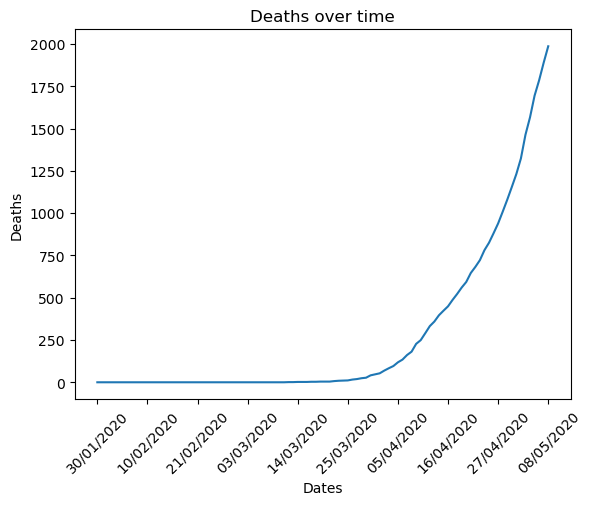

In [234]:
sns.lineplot(data = df,x ="Date",y ="Total Deceased")
plt.xticks(df["Date"][::11],rotation = 45)
plt.title("Deaths over time")
plt.xlabel("Dates")
plt.ylabel("Deaths")
plt.show()

### INSIGHT:
* As the rate of confirmed cases increases overtime the death rate increases simultaneously.

## RECOVERY OVERTIME

Question: How did the Recovery Rate change over time? 

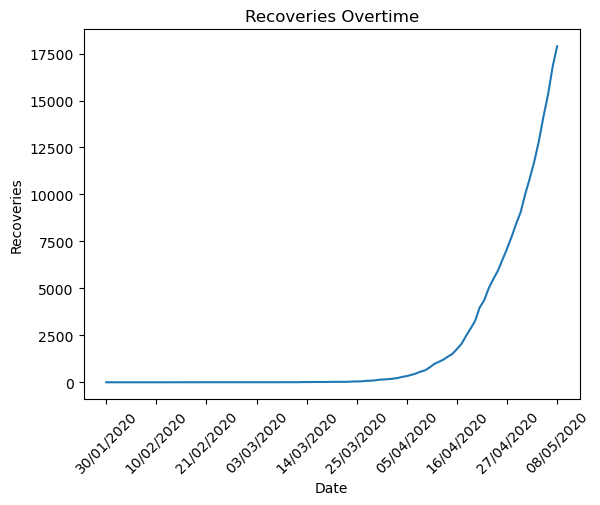

In [229]:
sns.lineplot(data=df,x="Date",y="Total Recovered")
plt.xticks(df["Date"][::11],rotation = 45)
plt.xlabel("Date")
plt.ylabel("Recoveries")
plt.title("Recoveries Overtime")
plt.show()

### INSIGHT
* As the rate of confirmed cases increases overtime the rate of Recoveries increases simultaneously.

## DISTRIBUTION OF DAILY CONFIRMED CASES 

Question:How does the rate of daily confirmed cases change over time?

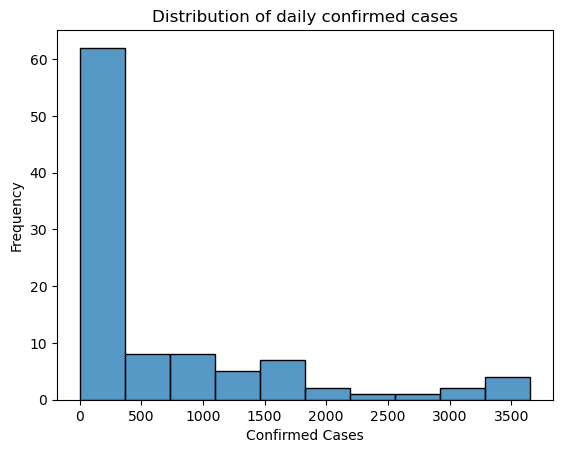

In [213]:
sns.histplot(df["Daily Confirmed"])
plt.title("Distribution of daily confirmed cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Frequency")
plt.show()

### INSIGHT:
* The rate of daily confirmed cases increases overtime but most of the confirmed cases was in between 0-500 

## OUTLIER DETECTION IN CONFIRMED CASES

Question:What were the outlier confirmed cases?

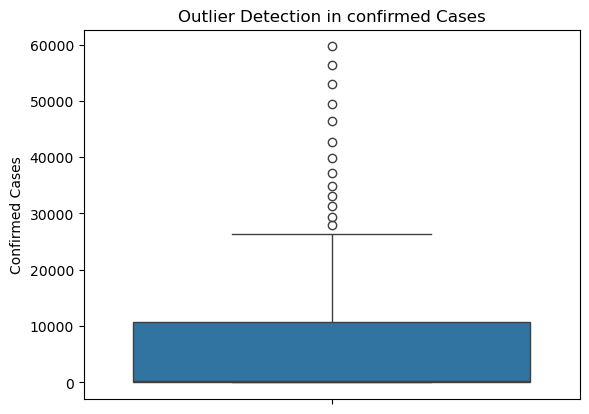

In [230]:
#Explaination
"""THE BOX PLOT SHOWS SEVERAL HIGHVALUE OUTLIERS IN CONFIRMED COVID-19 CASES(THE CIRCLES)
THIS INDICATES THERE ARE SOME HIGHER VALUE CONFIRMED CASES THAN MAJORITY OF CASES
* THE BLUE BOX (50% OF CONFIRMED CASES)
* THE MIDDLE LINE(MIDDLE VALUES)
* THE CIRCLES(EXTREMELY HIGHER VALUES)"""

sns.boxplot(y =df["Total Confirmed"])
plt.title("Outlier Detection in confirmed Cases")
plt.ylabel("Confirmed Cases")
plt.show()

### INSIGHT:
* The white circles are the outlier confirmed cases
* the rate of outlier confirmed cases increased 
starting between 20000-30000 extended till 60000.

## RELATIONSHIP BETWEEN CONFIRMED CASES AND DEATHS

Question:What is the relationship between confirmed cases and deaths 

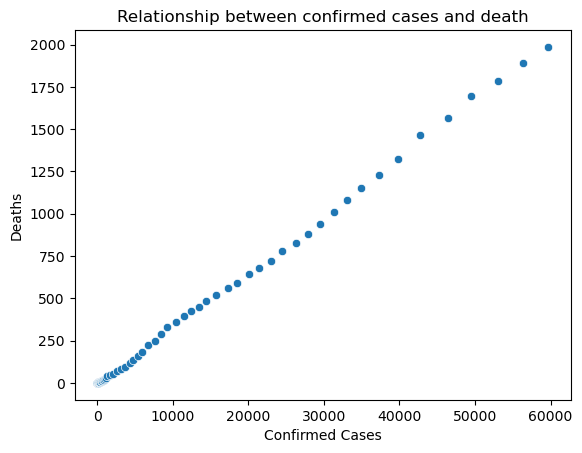

In [233]:
sns.scatterplot(data =df,x = "Total Confirmed",y ="Total Deceased")
plt.title("Relationship between confirmed cases and death")
plt.xlabel("Confirmed Cases")
plt.ylabel("Deaths")
plt.show()

### INSIGHT:
* As the Confirmed cases increases overtime the death rate increases simultaneously.

## CORRELATION BETWEEN CONFIRMED,RECOVERED AND DECREASED CASES

Question:Explain the correlation between Confirmed,Recovered and Deceased cases.

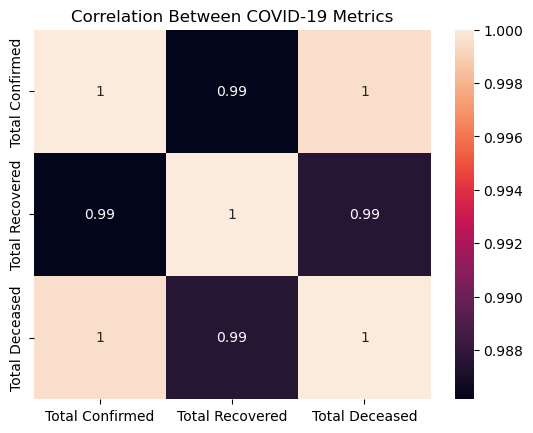

In [232]:
corr = df[["Total Confirmed", "Total Recovered", "Total Deceased"]].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Between COVID-19 Metrics")
plt.show()

### INSIGHT

#### 1. Correlation between Total Confirmed and Total Recovered is **0.99**

* This indicates a very strong positive relationship.
* Regions with higher confirmed cases generally have higher recoveries.

#### 2. Correlation between Total Confirmed and Total Deceased is **1.00**

* This indicates an almost perfect positive relationship.
* Regions with higher confirmed cases tend to report higher deaths.

#### 3. Correlation between Total Recovered and Total Deceased is **0.99**

* This indicates a very strong positive relationship.
* Areas with larger outbreaks generally show both higher recoveries and higher deaths.
